# 04 · Simulación del watermark
¿Cuántos eventos descartaría Spark Streaming si usáramos un watermark,
dado que cada micro-lote trae eventos de los 60 días?

In [1]:
#cargar recordando el orden de llegada

from pathlib import Path
import glob
import pandas as pd
import matplotlib.pyplot as plt

LANDING = Path('../data/datalake/landing')
archivos = sorted(glob.glob(str(LANDING / 'usage_events_stream' / '*.jsonl')))

partes = []
for i, a in enumerate(archivos):
    df = pd.read_json(a, lines=True)
    df['archivo_nro'] = i          # orden de llegada: archivo 0 llega primero, 119 último
    partes.append(df)
ev = pd.concat(partes, ignore_index=True)
ev['ts'] = pd.to_datetime(ev['timestamp'], utc=True)
print(f'{len(ev):,} eventos en {len(archivos)} archivos')

43,200 eventos en 120 archivos


In [2]:
#calcular el watermark al llegar cada archivi

# hora del evento más reciente que se vio HASTA el archivo anterior
max_por_archivo = ev.groupby('archivo_nro')['ts'].max()
max_visto_antes = max_por_archivo.cummax().shift(1)

ev['max_visto'] = ev['archivo_nro'].map(max_visto_antes)
max_visto_antes.head()

archivo_nro
0                         NaT
1   2025-08-31 16:32:00+00:00
2   2025-08-31 23:51:00+00:00
3   2025-08-31 23:51:00+00:00
4   2025-08-31 23:51:00+00:00
Name: ts, dtype: datetime64[us, UTC]

In [3]:
#probar distintos margenes

resultados = []
for margen in ['2h', '1D', '7D', '30D', '60D']:
    watermark = ev['max_visto'] - pd.Timedelta(margen)
    descartados = ev['ts'] < watermark
    resultados.append({'margen': margen, '% descartado': round(descartados.mean() * 100, 1)})

sim = pd.DataFrame(resultados)
sim

,margen,% descartado
0,2h,99.0
1,1D,97.5
2,7D,87.6
3,30D,49.6
4,60D,0.0


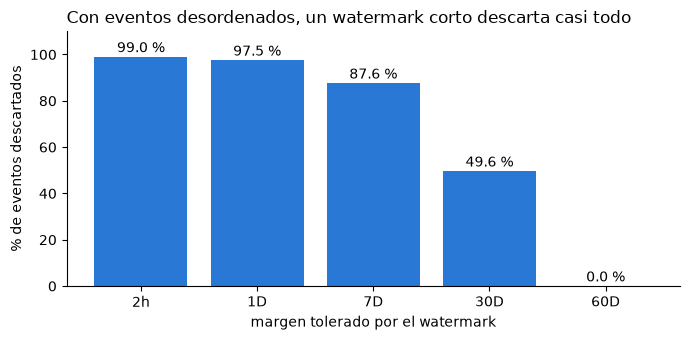

In [4]:
#grafico y evidencia

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(sim['margen'], sim['% descartado'], color='#2a78d6')
for i, v in enumerate(sim['% descartado']):
    ax.text(i, v + 2, f'{v} %', ha='center')
ax.set_ylim(0, 110)
ax.set_xlabel('margen tolerado por el watermark')
ax.set_ylabel('% de eventos descartados')
ax.set_title('Con eventos desordenados, un watermark corto descarta casi todo', loc='left')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()

EVIDENCIA = Path('../evidence'); EVIDENCIA.mkdir(exist_ok=True)
plt.savefig(EVIDENCIA / 'simulacion_watermark.png', dpi=120)
sim.to_csv(EVIDENCIA / 'simulacion_watermark.csv', index=False)
plt.show()

## Conclusión
Simulando la llegada de los 120 archivos en orden, un watermark descartaría:
2 h → 99 % · 1 día → 97,5 % · 7 días → 87,6 % · 30 días → 49,6 % · 60 días → 0 %.

Como cada micro-lote trae eventos de los 60 días, **no se puede agregar por ventanas de tiempo dentro del stream** sin perder casi todo el costo. Decisión de diseño:
1. El stream escribe Bronze y Silver en modo *append*, sin descartar eventos tardíos.
2. El watermark se usa solo para acotar la deduplicación por `event_id`.
3. Por cada lote se recalculan desde Silver las claves (org, fecha, servicio) que aparecieron y se hace *upsert* en Gold: correcto aunque el evento llegue tarde, e idempotente si se reprocesa.
4. Un cierre batch D+1 recalcula el día anterior completo como control.